In [1]:
import os

import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from pyproj import Geod
import numpy as np
import codes.utils.configs.city_clusters_config as city_clusters_config
from codes.utils.tools.io_tool import load_preprocessed_evcs


In [2]:
global_output_path = r'../data/output/plots/distribution//'

# Pie chart for collected data

In [4]:
cn_evcs = load_preprocessed_evcs('china')
us_evcs = load_preprocessed_evcs('usa')
eu_evcs = load_preprocessed_evcs('europe')

In [5]:
region_count = [len(cn_evcs), len(eu_evcs), len(us_evcs)]
region = ['China', 'Europe', 'USA']


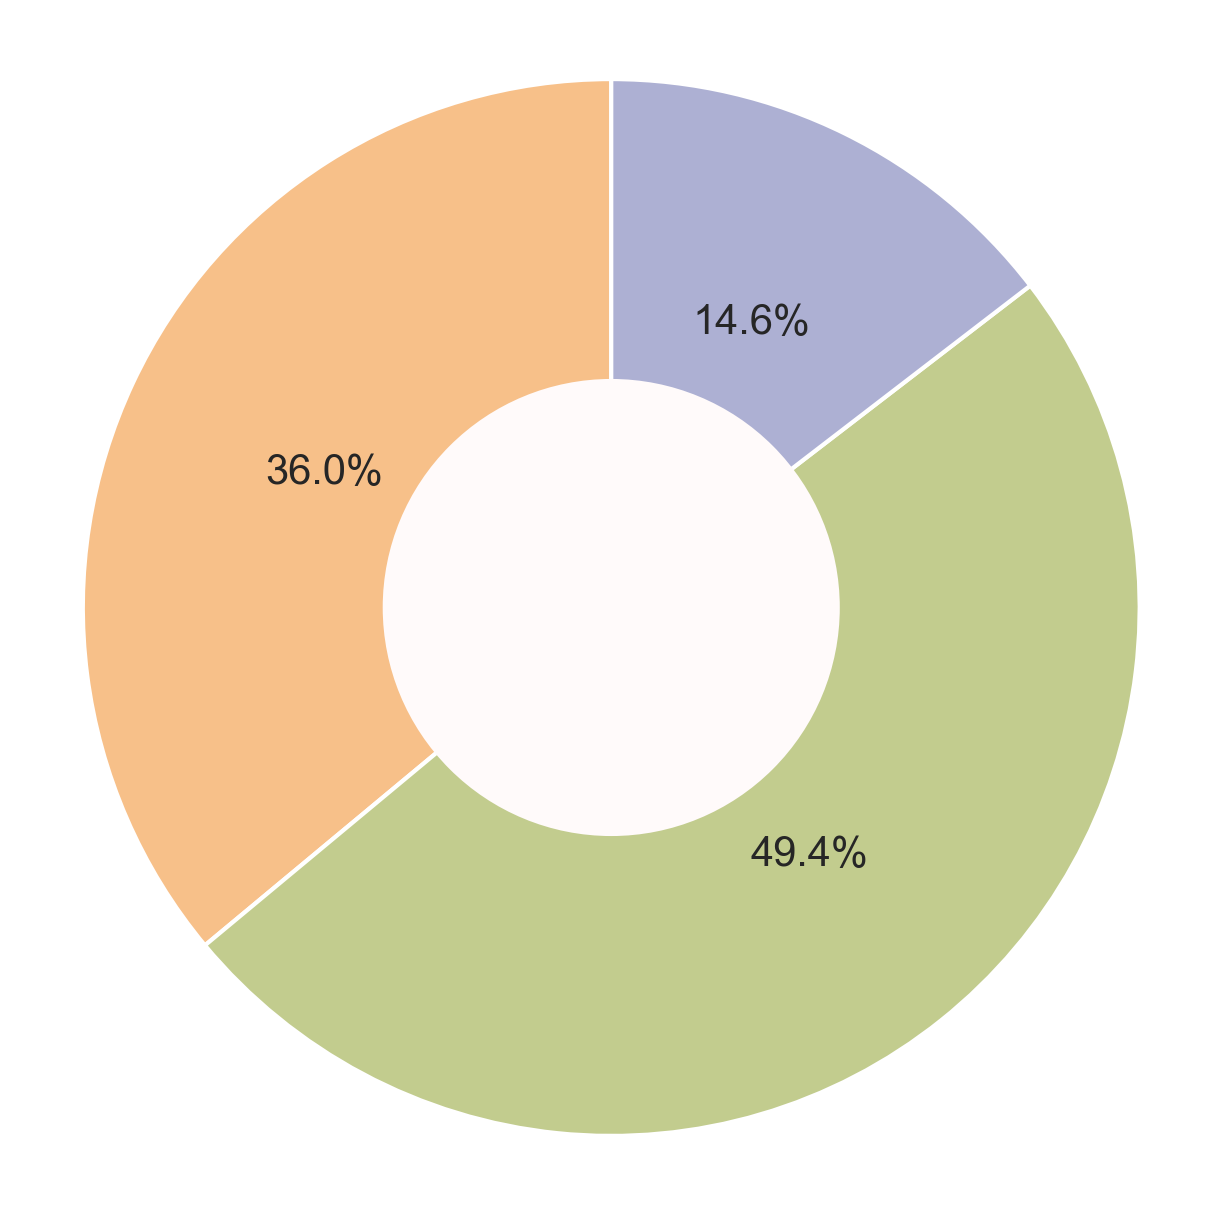

In [12]:
fig, ax = plt.subplots(figsize=(5, 5),
                       dpi=300)
# Plot the intermidiate pie
ax.pie(region_count,
       # labels=regions,
       autopct='%1.1f%%',
       radius=0.7,
       startangle=90,
       colors=['#F7C089', '#C2CC8E', '#ADB0D3'],
       wedgeprops={'edgecolor': 'white'})
# Plot the inner pie
center_circle = plt.Circle((0, 0), 0.3, color='snow')
ax.add_artist(center_circle)

ax.axis('equal')
fig.savefig(global_output_path + 'collected_data_distribution.png')
plt.show()

# Report number of EV charger in US

In [4]:
us_evcs_raw = gpd.read_file(r'../data/input/raw_data/evcs-geo/usa.geojson')
us_evcs_raw

,Station Name,Street Address,City,State,ZIP,Latitude,Longitude,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,geometry
0,Los Angeles Convention Center,1201 S Figueroa St,Los Angeles,CA,90015,34.040539,-118.271387,NaN,7.0,NaN,POINT (-118.27139 34.04054)
1,Scripps Green Hospital,10666 N Torrey Pines Rd,La Jolla,CA,92037,32.899470,-117.243000,NaN,1.0,NaN,POINT (-117.24300 32.89947)
2,Galpin Motors,15421 Roscoe Blvd,Sepulveda,CA,91343,34.221665,-118.468371,NaN,2.0,NaN,POINT (-118.46837 34.22167)
3,Galleria at Tyler,1299 Galleria at Tyler,Riverside,CA,92503,33.909914,-117.459053,NaN,4.0,NaN,POINT (-117.45905 33.90991)
4,City of Pasadena - Holly Street Garage,150 E Holly St,Pasadena,CA,91103,34.147620,-118.147111,NaN,16.0,NaN,POINT (-118.14711 34.14762)
...,...,...,...,...,...,...,...,...,...,...,...
69672,MAYPOWEREV MARYLAND AVE 2,2507 N Howard St,Baltimore,MD,21218,39.318455,-76.619573,NaN,2.0,NaN,POINT (-76.61957 39.31846)
69673,MAYPOWEREV MARYLAND AVE 1,2507 North Howard Street,Baltimore,MD,21218,39.318621,-76.619186,NaN,2.0,NaN,POINT (-76.61919 39.31862)
69674,AAA OR ID AAA-LKO2,5 Centerpointe Dr,Lake Oswego,OR,97035,45.421503,-122.740217,NaN,NaN,1.0,POINT (-122.74022 45.42150)
69675,Acme 3200-09 Red Lion Road,3200-09 Red Lion Road,Philadelphia,PA,19114,40.079462,-74.993385,NaN,2.0,NaN,POINT (-74.99339 40.07946)


In [6]:
us_city_bound = gpd.read_file(r'../data/input/boundary/usa/gadm41_USA_2.shp')
us_city_bound

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,area,geometry
0,USA.1.1_1,USA,United States,USA.1_1,Alabama,NA,Autauga,NA,NA,County,County,NA,US.AL.AU,1561.763481,"POLYGON ((-86.91668 32.66431, -86.82678 32.660..."
1,USA.1.2_1,USA,United States,USA.1_1,Alabama,NA,Baldwin,NA,NA,County,County,NA,US.AL.BD,4243.445852,"MULTIPOLYGON (((-87.74416 30.29445, -87.74389 ..."
2,USA.1.3_1,USA,United States,USA.1_1,Alabama,NA,Barbour,NA,NA,County,County,NA,US.AL.BR,2328.492853,"POLYGON ((-85.41607 31.61962, -85.49133 31.620..."
3,USA.1.4_1,USA,United States,USA.1_1,Alabama,NA,Bibb,NA,NA,County,County,NA,US.AL.BI,1620.617826,"POLYGON ((-87.42078 32.87446, -87.42028 32.971..."
4,USA.1.5_1,USA,United States,USA.1_1,Alabama,NA,Blount,NA,NA,County,County,NA,US.AL.BU,1691.661331,"POLYGON ((-86.96287 33.85858, -86.96512 33.863..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3143,USA.51.19_1,USA,United States,USA.51_1,Wyoming,NA,Sweetwater,NA,NA,County,County,NA,US.WY.SW,27169.582833,"POLYGON ((-107.91540 41.00295, -107.96598 41.0..."
3144,USA.51.20_1,USA,United States,USA.51_1,Wyoming,NA,Teton,NA,NA,County,County,NA,US.WY.TE,10916.672055,"POLYGON ((-111.04362 43.31358, -111.04391 43.4..."
3145,USA.51.21_1,USA,United States,USA.51_1,Wyoming,NA,Uinta,NA,NA,County,County,NA,US.WY.UI,5396.736869,"POLYGON ((-111.04584 41.25143, -111.04594 41.3..."
3146,USA.51.22_1,USA,United States,USA.51_1,Wyoming,NA,Washakie,NA,NA,County,County,NA,US.WY.WA,5834.244312,"POLYGON ((-108.55055 44.16851, -107.14581 44.1..."


In [20]:
us_city_bound[us_city_bound['HASC_2'].isna()]

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,area,geometry


In [7]:
# Sjoin to get the city (NAME_2 and HASC_2) name
us_evcs_with_boundary = gpd.sjoin(us_evcs_raw, us_city_bound, how='left', op='within')
us_evcs_with_boundary

D:\anaconda3\envs\TransAndGeo\lib\site-packages\IPython\core\interactiveshell.py:3493: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


,Station Name,Street Address,City,State,ZIP,Latitude,Longitude,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,...,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,area
0,Los Angeles Convention Center,1201 S Figueroa St,Los Angeles,CA,90015,34.040539,-118.271387,NaN,7.0,NaN,...,California,NA,Los Angeles,NA,NA,County,County,NA,US.CA.LO,10582.858821
1,Scripps Green Hospital,10666 N Torrey Pines Rd,La Jolla,CA,92037,32.899470,-117.243000,NaN,1.0,NaN,...,California,NA,San Diego,NA,NA,County,County,NA,US.CA.SD,10992.832709
2,Galpin Motors,15421 Roscoe Blvd,Sepulveda,CA,91343,34.221665,-118.468371,NaN,2.0,NaN,...,California,NA,Los Angeles,NA,NA,County,County,NA,US.CA.LO,10582.858821
3,Galleria at Tyler,1299 Galleria at Tyler,Riverside,CA,92503,33.909914,-117.459053,NaN,4.0,NaN,...,California,NA,Riverside,NA,NA,County,County,NA,US.CA.RI,18943.198592
4,City of Pasadena - Holly Street Garage,150 E Holly St,Pasadena,CA,91103,34.147620,-118.147111,NaN,16.0,NaN,...,California,NA,Los Angeles,NA,NA,County,County,NA,US.CA.LO,10582.858821
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69672,MAYPOWEREV MARYLAND AVE 2,2507 N Howard St,Baltimore,MD,21218,39.318455,-76.619573,NaN,2.0,NaN,...,Maryland,NA,Baltimore,NA,NA,County,County,NA,US.MD.BA,1794.623509
69673,MAYPOWEREV MARYLAND AVE 1,2507 North Howard Street,Baltimore,MD,21218,39.318621,-76.619186,NaN,2.0,NaN,...,Maryland,NA,Baltimore,NA,NA,County,County,NA,US.MD.BA,1794.623509
69674,AAA OR ID AAA-LKO2,5 Centerpointe Dr,Lake Oswego,OR,97035,45.421503,-122.740217,NaN,NaN,1.0,...,Oregon,NA,Clackamas,NA,NA,County,County,NA,US.OR.CC,4886.275256
69675,Acme 3200-09 Red Lion Road,3200-09 Red Lion Road,Philadelphia,PA,19114,40.079462,-74.993385,NaN,2.0,NaN,...,Pennsylvania,NA,Philadelphia,NA,NA,County,County,NA,US.PA.PH,368.523944


In [12]:
len(us_evcs_with_boundary['HASC_2'].unique())

2245

In [19]:
us_evcs_with_boundary[us_evcs_with_boundary['HASC_2'].isna()]

,Station Name,Street Address,City,State,ZIP,Latitude,Longitude,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,...,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,area,charger_sum
64,Rio Vista City Hall,1 Main St,Rio Vista,CA,94571,38.154850,-121.690000,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
756,Four Seasons Resort Hualalai,72-100 Kaupulehu Drive,Kailua-Kona,HI,96740,19.828181,-155.994896,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
4223,RI ENERGY FORT ADAMS,10 Fort Adams Dr,Newport,RI,2840,41.477130,-71.335543,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
6181,A1A Motel - Tesla Destination,1204 S Oceanshore Blvd,Flagler Beach,FL,32136,29.473686,-81.124128,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
6825,Stones Throw - Tesla Destination,123 Long Beach Ave,York,ME,3909,43.166231,-70.615842,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
6958,Beau Rivage Resort & Casino - Garage 2nd Floor...,875 Beach Blvd,Biloxi,MS,39530,30.393664,-88.893472,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
7506,imPark 611 E 83rd Street - Tesla Destination,611 E 83rd St,New York,NY,10028,40.772681,-73.945488,NaN,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
7813,"Gurney's Resort, Newport - Tesla Destination",1 Goat Island,Newport,RI,2840,41.491410,-71.327394,NaN,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0
8635,Cordova Center - Upper,604 1st St,Cordova,AK,99574,60.544088,-145.759026,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
8636,Cordova Center - Lower,502 Railroad Ave,Cordova,AK,99574,60.544470,-145.759782,NaN,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


In [9]:
us_evcs_with_boundary['charger_sum'] = us_evcs_with_boundary[['EV Level1 EVSE Num', 'EV Level2 EVSE Num', 'EV DC Fast Count']].sum(axis=1)
us_evcs_with_boundary

,Station Name,Street Address,City,State,ZIP,Latitude,Longitude,EV Level1 EVSE Num,EV Level2 EVSE Num,EV DC Fast Count,...,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,area,charger_sum
0,Los Angeles Convention Center,1201 S Figueroa St,Los Angeles,CA,90015,34.040539,-118.271387,NaN,7.0,NaN,...,NA,Los Angeles,NA,NA,County,County,NA,US.CA.LO,10582.858821,7.0
1,Scripps Green Hospital,10666 N Torrey Pines Rd,La Jolla,CA,92037,32.899470,-117.243000,NaN,1.0,NaN,...,NA,San Diego,NA,NA,County,County,NA,US.CA.SD,10992.832709,1.0
2,Galpin Motors,15421 Roscoe Blvd,Sepulveda,CA,91343,34.221665,-118.468371,NaN,2.0,NaN,...,NA,Los Angeles,NA,NA,County,County,NA,US.CA.LO,10582.858821,2.0
3,Galleria at Tyler,1299 Galleria at Tyler,Riverside,CA,92503,33.909914,-117.459053,NaN,4.0,NaN,...,NA,Riverside,NA,NA,County,County,NA,US.CA.RI,18943.198592,4.0
4,City of Pasadena - Holly Street Garage,150 E Holly St,Pasadena,CA,91103,34.147620,-118.147111,NaN,16.0,NaN,...,NA,Los Angeles,NA,NA,County,County,NA,US.CA.LO,10582.858821,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69672,MAYPOWEREV MARYLAND AVE 2,2507 N Howard St,Baltimore,MD,21218,39.318455,-76.619573,NaN,2.0,NaN,...,NA,Baltimore,NA,NA,County,County,NA,US.MD.BA,1794.623509,2.0
69673,MAYPOWEREV MARYLAND AVE 1,2507 North Howard Street,Baltimore,MD,21218,39.318621,-76.619186,NaN,2.0,NaN,...,NA,Baltimore,NA,NA,County,County,NA,US.MD.BA,1794.623509,2.0
69674,AAA OR ID AAA-LKO2,5 Centerpointe Dr,Lake Oswego,OR,97035,45.421503,-122.740217,NaN,NaN,1.0,...,NA,Clackamas,NA,NA,County,County,NA,US.OR.CC,4886.275256,1.0
69675,Acme 3200-09 Red Lion Road,3200-09 Red Lion Road,Philadelphia,PA,19114,40.079462,-74.993385,NaN,2.0,NaN,...,NA,Philadelphia,NA,NA,County,County,NA,US.PA.PH,368.523944,2.0


In [10]:
us_county_level_evcs = us_evcs_with_boundary.pivot_table(index='HASC_2', 
                                                         values='charger_sum', 
                                                         aggfunc='sum'
                                                         ).reset_index()
us_county_level_evcs

,HASC_2,charger_sum
0,NA,4.0
1,US.AK.AN,37.0
2,US.AK.DE,9.0
3,US.AK.FA,2.0
4,US.AK.JU,27.0
...,...,...
2239,US.WY.SH,8.0
2240,US.WY.SU,2.0
2241,US.WY.SW,23.0
2242,US.WY.TE,61.0


In [18]:
set(us_evcs_with_boundary['HASC_2'].unique().tolist()).difference(set(us_county_level_evcs['HASC_2'].unique().tolist()))

{nan}

In [17]:
us_evcs_with_boundary['charger_sum'].sum()

195854.0

In [16]:
us_county_level_evcs['charger_sum'].sum()

195729.0

## Bay Area

In [21]:
us_county_level_evcs.query('HASC_2 in @city_clusters_config.BAY_AREA')['charger_sum'].sum() / us_evcs_with_boundary['charger_sum'].sum() 

0.07665914405628682

## NM

In [24]:
us_county_level_evcs.query('HASC_2 in @city_clusters_config.NM')['charger_sum'].sum() / us_evcs_with_boundary['charger_sum'].sum()

0.17569209717442585

# Regression plot for EVCS and GDP

In [3]:
def plot_gdp_evcs(dataset: pd.DataFrame or gpd.GeoDataFrame,
                  region: str,
                  x_col: str,  # GDP column name
                  y1_col: str,  # EVCS number
                  y2_col: str,  # EVCS density

                  backgroud_color: str or tuple,
                  back_alpha: float,

                  line1_color: str or tuple,  # EVCS number line
                  line2_color: str or tuple,  # EVCS density line

                  y1_lim: list[float or int],
                  y2_lim: list[float or int],

                  x_nbins: int,  # x-axis bins
                  y1_nbins: int,  # y1-axis bins
                  y2_nbins: int,  # y2-axis bins

                  fig_height=4,
                  fig_width=6,
                    
                  legend_loc='best',

                  x_label='GDP (billion yuan)',
                  output: bool = False,
                  output_filename='gdp_evcs.png'
                  ):
    # Create a FacetGrid object
    grid = sns.FacetGrid(data=dataset)
    grid.fig.set_figheight(fig_height)
    grid.fig.set_figwidth(fig_width)
    grid.fig.set_dpi(500)

    # Use map function to plot lmplot for the first dataset
    grid.map(sns.regplot,
             x_col,
             y1_col,
             color=line1_color,  # '#D7730F'
             label='EV charger number')

    # Set the y-axis label for the first dataset

    grid.ax.set_ylabel('EV charger number',
                       fontdict={'family': 'Times New Roman'},
                       color='k',
                       fontsize=16,
                       labelpad=4, fontweight='bold')

    grid.ax.set_xlabel(x_label,
                       fontdict={'family': 'Times New Roman'},
                       color='k',
                       fontsize=16,
                       labelpad=4, fontweight='bold')
    # Create a twin axes object
    ax2 = grid.axes.flatten()[0].twinx()

    # Plot lmplot for the second dataset on the twin axes
    sns.regplot(x=x_col,
                y=y2_col,
                data=dataset,
                color=line2_color,  # '#546e7a'
                ax=ax2,
                label='EV charger density')

    # Set the y-axis label for the second dataset
    ax2.set_ylabel('EV charger density (num/km$^{\mathregular{2}}$)',
                   fontdict={'family': 'Times New Roman'},
                   color='k',
                   fontsize=16,
                   labelpad=4,
                   fontweight='bold'
                   )
    ax2.set_xlabel(x_label,
                   fontdict={'family': 'Times New Roman'},
                   color='k',
                   fontsize=16,
                   labelpad=4, fontweight='bold')

    # Remove the right spine of the twin axes
    ax2.spines['right'].set_visible(True)

    grid.ax.set_facecolor(backgroud_color)  # '#fff3e0'
    grid.ax.patch.set_alpha(back_alpha)  # default--0.5

    for tem_yt in grid.ax.get_yticklabels():
        tem_yt.set_family('Times New Roman')
        tem_yt.set_fontsize(13)

    for tem_yt in grid.ax.get_xticklabels():
        tem_yt.set_family('Times New Roman')
        tem_yt.set_fontsize(13)

    for tem_xt in ax2.get_xticklabels():
        tem_xt.set_family('Times New Roman')
        tem_xt.set_fontsize(13)

    for tem_xt in ax2.get_yticklabels():
        tem_xt.set_family('Times New Roman')
        tem_xt.set_fontsize(13)
    
    grid.ax.set_ylim(y1_lim[0], y1_lim[1])  # -1000, 13000
    ax2.set_ylim(y2_lim[0], y2_lim[1])  # -0.0714, 0.9

    grid.ax.xaxis.set_major_locator(MaxNLocator(nbins=x_nbins))
    grid.ax.yaxis.set_major_locator(MaxNLocator(nbins=y1_nbins))
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=y2_nbins))
    
    grid.ax.grid(False)
    ax2.grid(False)
    
    grid.ax.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_ticks_position('bottom')
    
    ''' Legend '''
    handles1, labels1 = grid.ax.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    all_handles = handles1 + handles2
    all_labels = labels1 + labels2

    # Style 1:
    legend = plt.legend(all_handles, all_labels,
                            loc=legend_loc,
                            markerscale=1.5,
                            frameon=True,
                            facecolor='w',
                            edgecolor='grey',
                            prop={'family': 'Times New Roman',
                                  'size': 12}
                            )
    # legend.get_frame().set_linestyle('--')
    legend.get_frame().set_linewidth(0.5)
    
    # Add borders
    for spine in grid.ax.spines.values():
        spine.set_edgecolor('black')
    for spine in ax2.spines.values():
        spine.set_edgecolor('black')
    
    # Adjust the layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()

    # Save
    if output:
        try:
            os.makedirs(global_output_path)
        except FileExistsError:
            pass
        grid.figure.savefig(global_output_path + output_filename, dpi=500)

In [4]:
def geodesic_area(geom):
    geod = Geod(ellps="WGS84")
    if geom.is_empty:
        return np.nan
    try:
        area, _ = geod.geometry_area_perimeter(geom)
        return abs(area) / (1000 * 1000)
    except Exception as e:
        print(f"fail: {e}")
        return np.nan

In [6]:
from statsmodels import api as sm
def simple_regplot(
        x, y, n_std=2, n_pts=100, ax=None, scatter_kws=None, line_kws=None, ci_kws=None
):
    """ Draw a regression line with error interval. """
    ax = plt.gca() if ax is None else ax

    # calculate best-fit line and interval
    x_fit = sm.add_constant(x)
    fit_results = sm.OLS(y, x_fit).fit()

    eval_x = sm.add_constant(np.linspace(np.min(x), np.max(x), n_pts))
    pred = fit_results.get_prediction(eval_x)

    # draw the fit line and error interval
    ci_kws = {} if ci_kws is None else ci_kws
    ax.fill_between(
        eval_x[:, 1],
        pred.predicted_mean - n_std * pred.se_mean,
        pred.predicted_mean + n_std * pred.se_mean,
        alpha=0.5,
        **ci_kws,
    )
    line_kws = {} if line_kws is None else line_kws
    h = ax.plot(eval_x[:, 1], pred.predicted_mean, **line_kws)

    # draw the scatterplot
    scatter_kws = {} if scatter_kws is None else scatter_kws
    ax.scatter(x, y, c=h[0].get_color(), **scatter_kws)

    return fit_results

## China

In [7]:
cn_prov_boundary = gpd.read_file(r'../data/input/boundary/china/省级.zip')
# cn_prov_boundary

In [8]:
cn_prov_boundary['area'] = cn_prov_boundary['geometry'].apply(geodesic_area)
# cn_prov_boundary

In [9]:
cn_evcs_gdp_texts = pd.read_excel(r'../data/interim/support/gdp2024/China.xlsx')
# cn_evcs_gdp_texts

In [10]:
cn_evcs_gdp_with_area = cn_evcs_gdp_texts.merge(cn_prov_boundary[['省', 'area']], left_on='Province', right_on='省', how='left')
# cn_evcs_gdp_with_area

In [11]:
cn_evcs_gdp_with_area['evcs_density'] = cn_evcs_gdp_with_area['Public charger number'] / cn_evcs_gdp_with_area['area']
# cn_evcs_gdp_with_area

In [12]:
cn_evcs_gdp_with_area['GDP (billion dollar)'] = cn_evcs_gdp_with_area['GDP (billion yuan)'] / (1/0.1393)

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     Public charger number   R-squared:                       0.780
Model:                               OLS   Adj. R-squared:                  0.772
Method:                    Least Squares   F-statistic:                     102.7
Date:                   Thu, 06 Mar 2025   Prob (F-statistic):           4.86e-11
Time:                           16:03:14   Log-Likelihood:                -384.79
No. Observations:                     31   AIC:                             773.6
Df Residuals:                         29   BIC:                             776.5
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                -2.548e+04   1.78e+04     -1.435      0.162   -6.18e+04    1.08e+04
GDP (billion dollar)   233.8214     23.070     10.135      0.000     186.638     281.004
==============================================================================
Omnibus:                       22.001   Durbin-Watson:                   2.058
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               52.898
Skew:                           1.363   Prob(JB):                     3.26e-12
Kurtosis:                       8.790   Cond. No.                     1.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

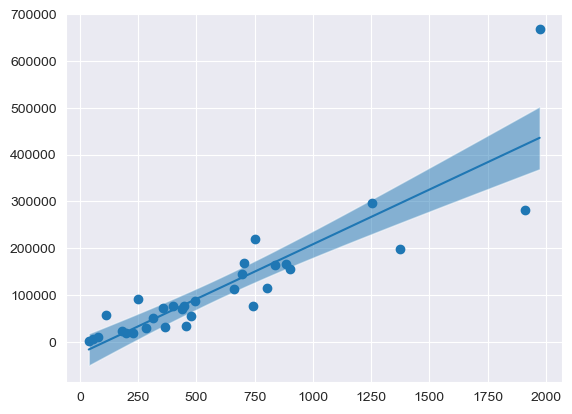

In [13]:
cn_reg = simple_regplot(cn_evcs_gdp_with_area['GDP (billion dollar)'], cn_evcs_gdp_with_area['Public charger number'])
cn_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           evcs_density   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9666
Date:                Thu, 06 Mar 2025   Prob (F-statistic):              0.334
Time:                        16:03:37   Log-Likelihood:                -93.076
No. Observations:                  31   AIC:                             190.2
Df Residuals:                      29   BIC:                             193.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.9518      1.454      0.655      0.518      -2.021       3.925
GDP (billion dollar)     0.0019      0.002      0.983      0.334      -0.002       0.006
==============================================================================
Omnibus:                       61.059   Durbin-Watson:                   2.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              491.468
Skew:                           4.191   Prob(JB):                    1.90e-107
Kurtosis:                      20.613   Cond. No.                     1.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

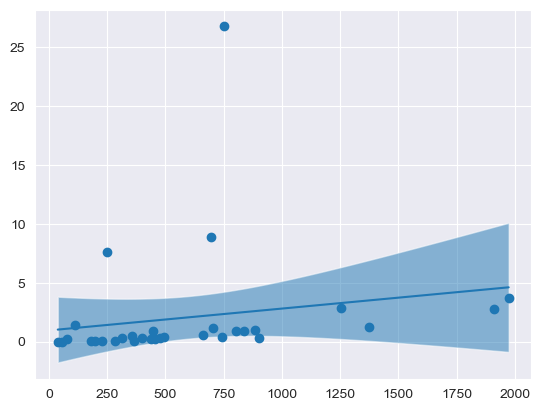

In [14]:
cn_reg = simple_regplot(cn_evcs_gdp_with_area['GDP (billion dollar)'], cn_evcs_gdp_with_area['evcs_density'])
cn_reg.summary()

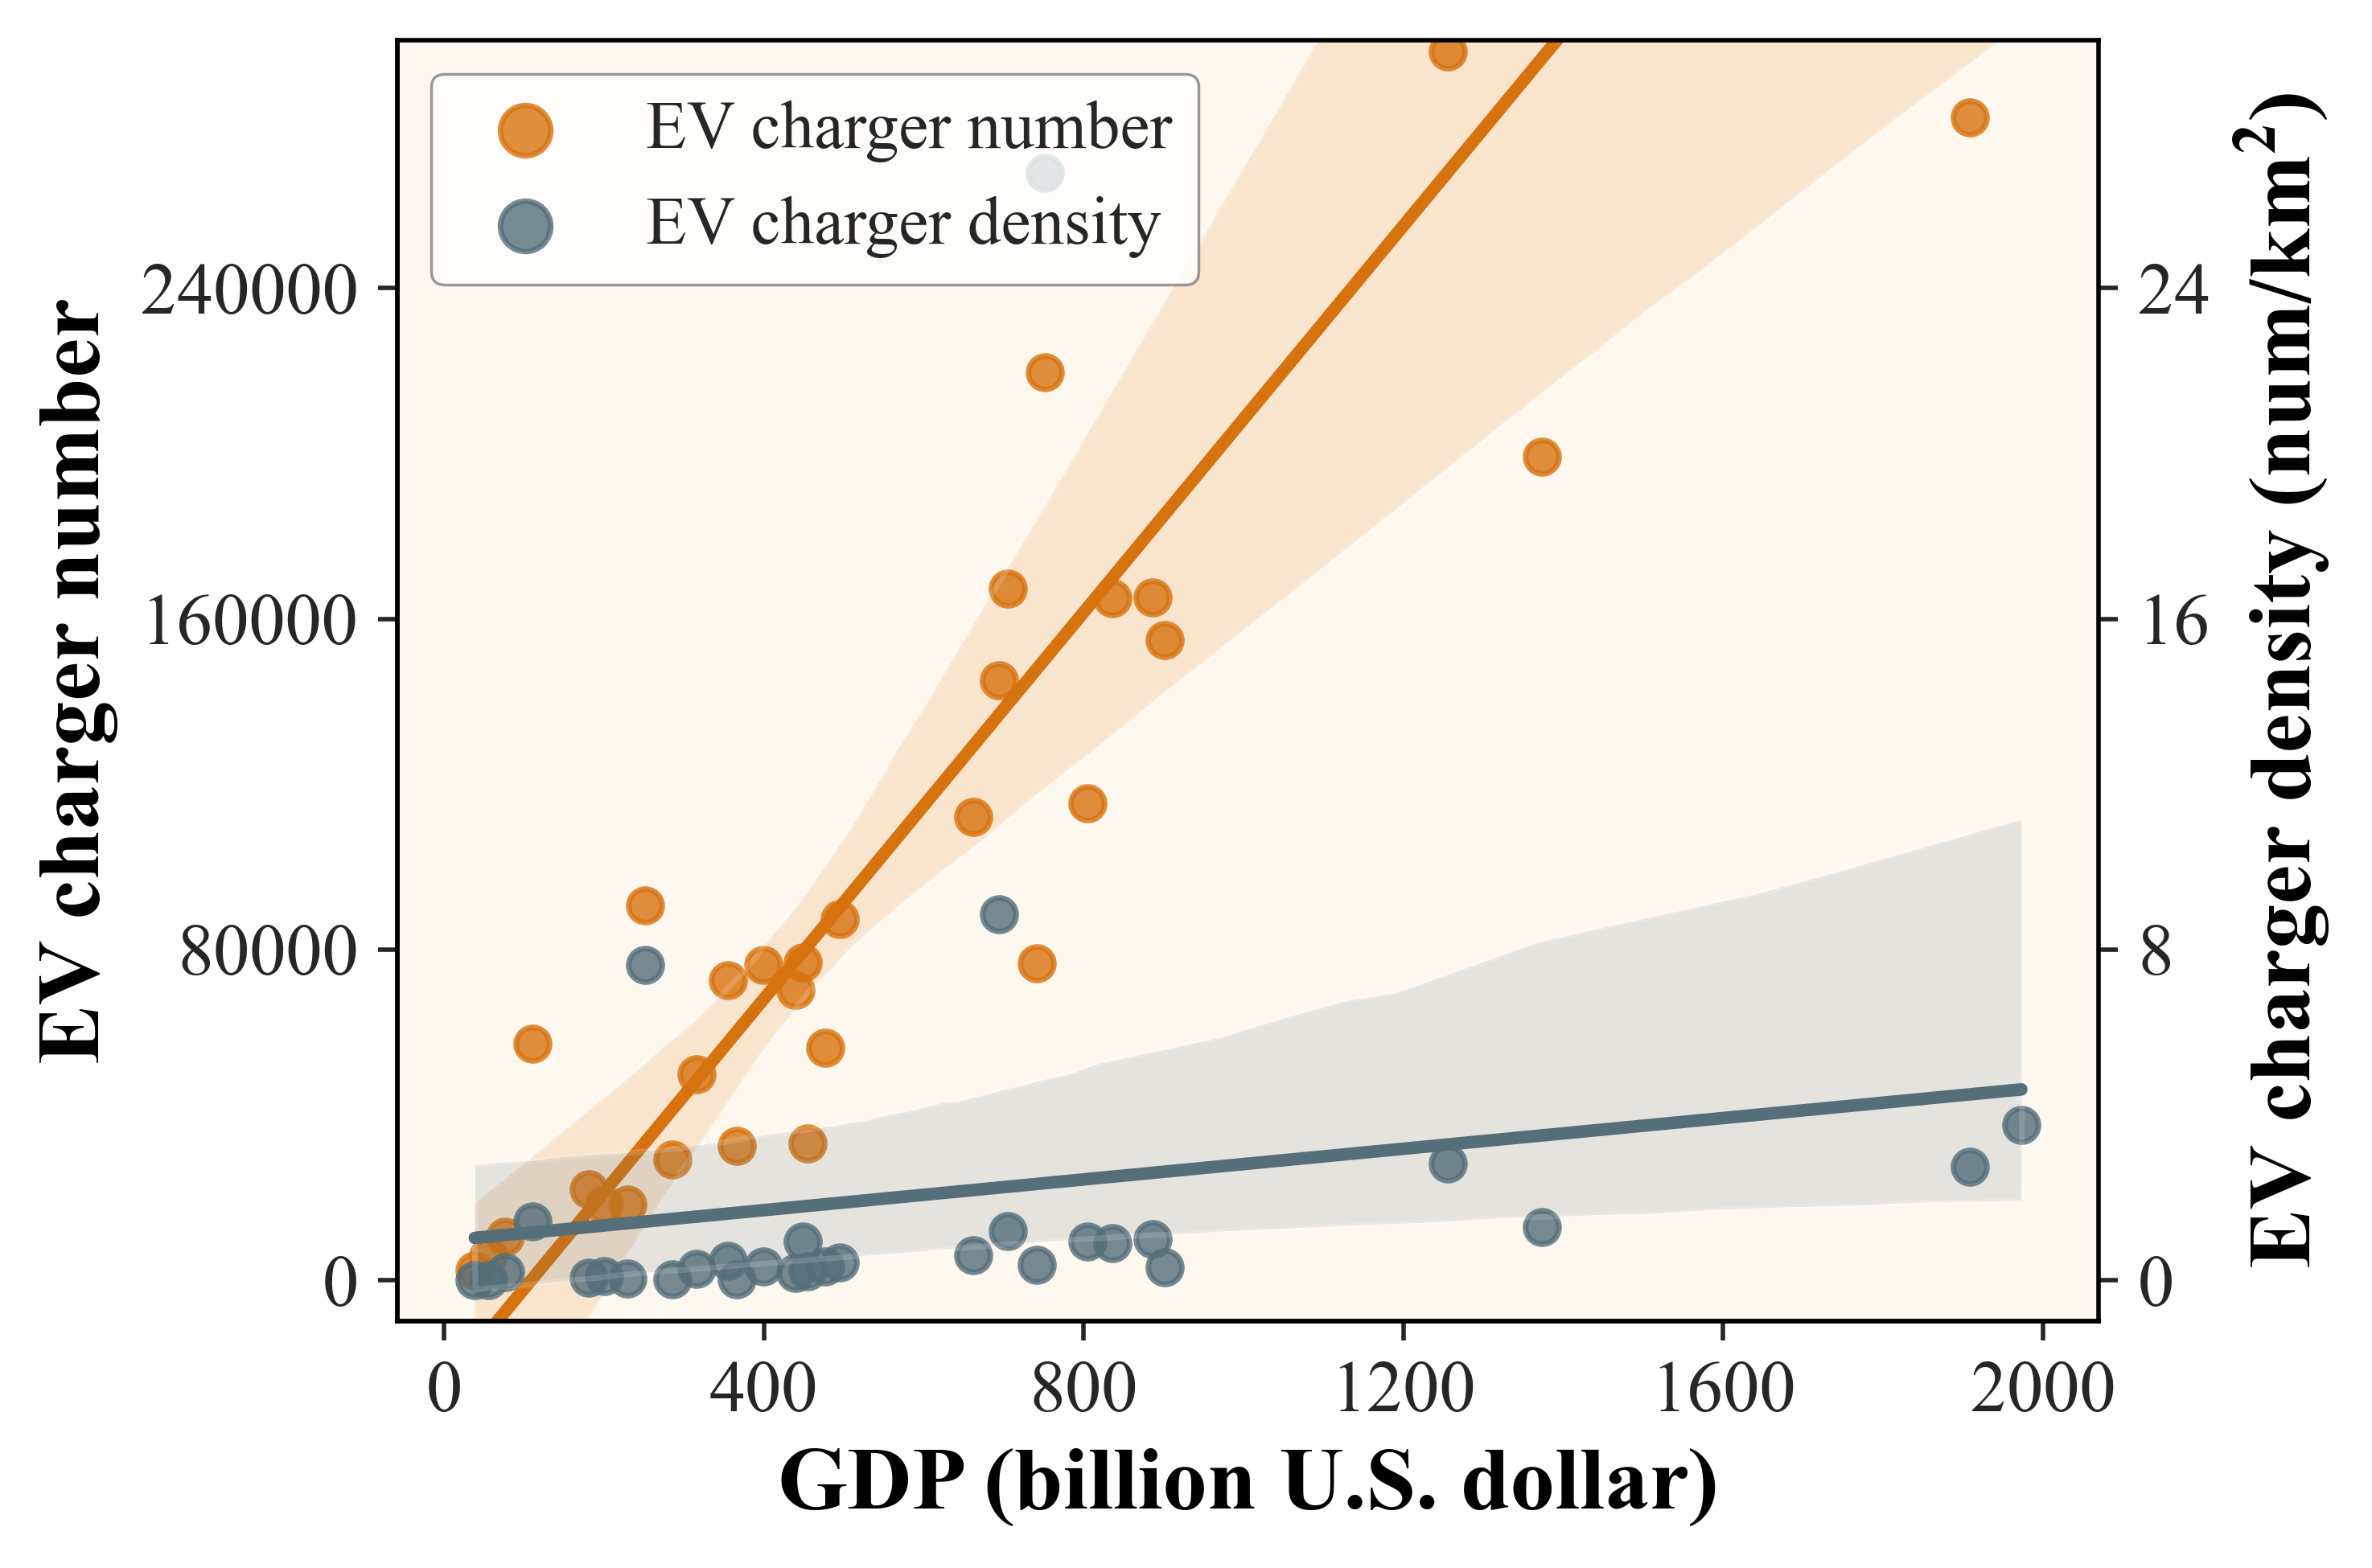

In [30]:
plot_gdp_evcs(dataset=cn_evcs_gdp_with_area,
              region='China',
              x_col='GDP (billion dollar)',
              y1_col='Public charger number',
              y2_col='evcs_density',
              backgroud_color='#fff3e0',
              back_alpha=0.5,
              line1_color='#D7730F',
              line2_color='#546e7a',
              y1_lim=[-10000, 300000],
              y2_lim=[-1, 30],
              x_nbins=6,
              y1_nbins=5,
              y2_nbins=5,
              x_label='GDP (billion U.S. dollar)',
              legend_loc='upper left',
              output=True,
              output_filename='gdp_evcs_china.png'
              )

## Europe

In [15]:
eu_country_boundary = gpd.read_file(r'../data/input/boundary/europe/europe_country_boundary.shp.zip')
# eu_country_boundary

In [16]:
eu_gdp_evcs_texts = pd.read_excel(r'../data/interim/support/gdp2024/Europe.xlsx')
# eu_gdp_evcs_texts

In [17]:
eu_gdp_evcs_with_area = eu_gdp_evcs_texts.merge(eu_country_boundary, left_on='Country', right_on='COUNTRY', how='left')
# eu_gdp_evcs_with_area

In [18]:
eu_gdp_evcs_with_area['evcs_density'] = eu_gdp_evcs_with_area['Public charger number'] / eu_gdp_evcs_with_area['area']
# eu_gdp_evcs_with_area

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     Public charger number   R-squared:                       0.624
Model:                               OLS   Adj. R-squared:                  0.612
Method:                    Least Squares   F-statistic:                     49.82
Date:                   Thu, 06 Mar 2025   Prob (F-statistic):           7.57e-08
Time:                           16:04:54   Log-Likelihood:                -375.36
No. Observations:                     32   AIC:                             754.7
Df Residuals:                         30   BIC:                             757.7
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                     5587.5037   6634.775      0.842      0.406   -7962.514    1.91e+04
GDP (billion US dollars)    34.3851      4.871      7.058      0.000      24.436      44.334
==============================================================================
Omnibus:                       44.500   Durbin-Watson:                   1.826
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              190.569
Skew:                           2.935   Prob(JB):                     4.15e-42
Kurtosis:                      13.415   Cond. No.                     1.65e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

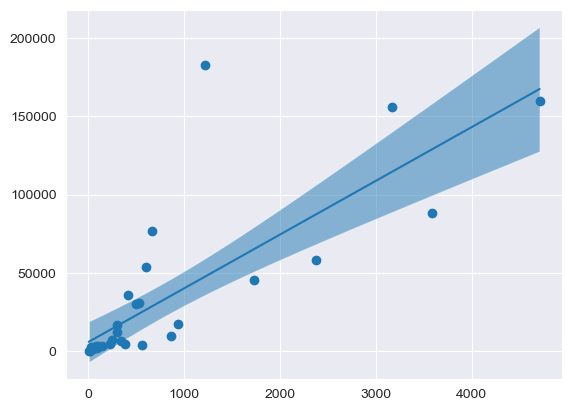

In [19]:
eu_reg = simple_regplot(eu_gdp_evcs_with_area['GDP (billion US dollars)'], eu_gdp_evcs_with_area['Public charger number'])
eu_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           evcs_density   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.022
Method:                 Least Squares   F-statistic:                    0.3316
Date:                Thu, 06 Mar 2025   Prob (F-statistic):              0.569
Time:                        16:05:11   Log-Likelihood:                -42.696
No. Observations:                  32   AIC:                             89.39
Df Residuals:                      30   BIC:                             92.32
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.3578      0.203      1.765      0.088      -0.056       0.772
GDP (billion US dollars)  8.572e-05      0.000      0.576      0.569      -0.000       0.000
==============================================================================
Omnibus:                       55.620   Durbin-Watson:                   1.383
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              344.195
Skew:                           3.764   Prob(JB):                     1.82e-75
Kurtosis:                      17.194   Cond. No.                     1.65e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

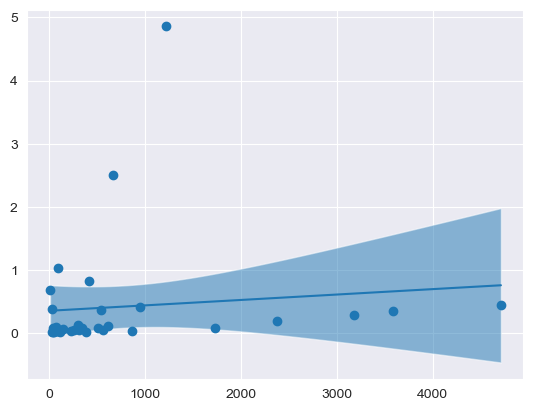

In [20]:
eu_reg = simple_regplot(eu_gdp_evcs_with_area['GDP (billion US dollars)'], eu_gdp_evcs_with_area['evcs_density'])
eu_reg.summary()

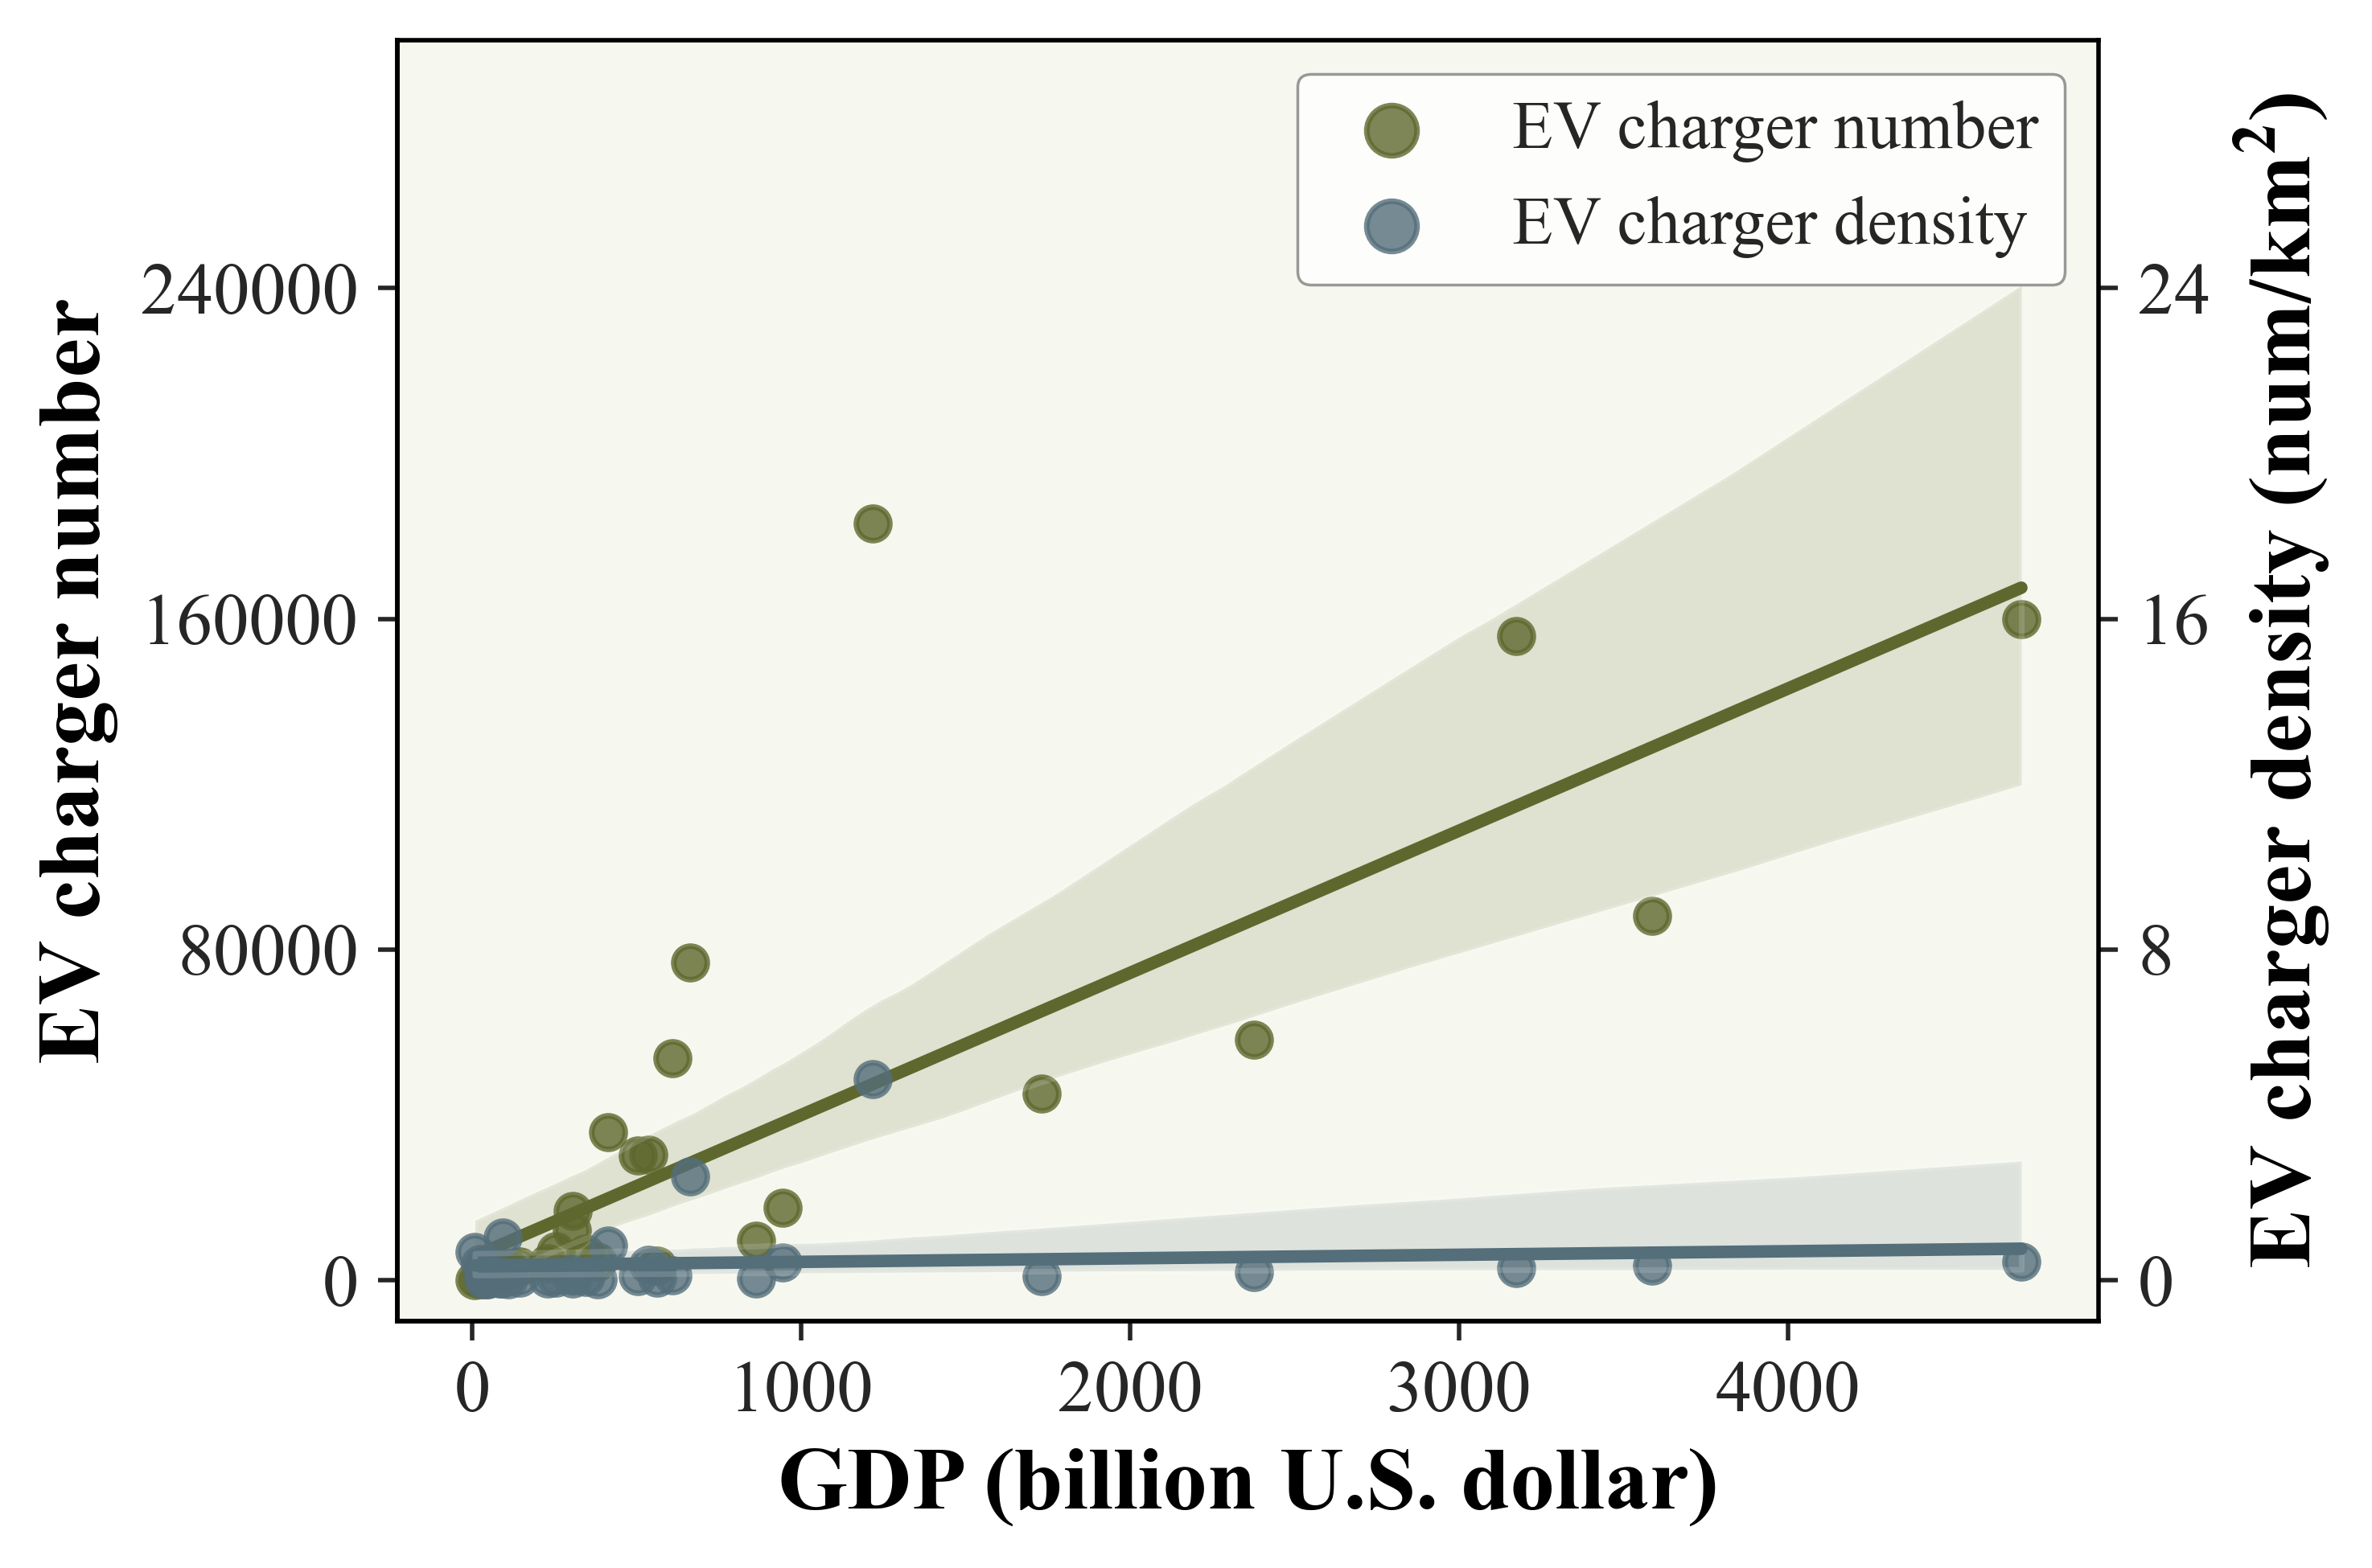

In [29]:
plot_gdp_evcs(dataset=eu_gdp_evcs_with_area,
              region='Europe',
              x_col='GDP (billion US dollars)',
              y1_col='Public charger number',
              y2_col='evcs_density',
              backgroud_color='#EEF1DF',
              back_alpha=0.5,
              line1_color='#5E682E',
              line2_color='#546e7a',
              y1_lim=[-10000, 300000],
              y2_lim=[-1, 30],
              x_nbins=6,
              y1_nbins=5,
              y2_nbins=5,
              x_label='GDP (billion U.S. dollar)',
              legend_loc='best',
              output=True,
              output_filename='gdp_evcs_europe.png'
              )

## USA

In [21]:
us_state_boundary = gpd.read_file(r'../data/input/boundary/usa/gadm41_USA_1.shp')
# us_state_boundary

In [22]:
us_gdp_evcs_texts = pd.read_excel(r'../data/interim/support/gdp2024/US.xlsx')
# us_gdp_evcs_texts

In [23]:
us_gdp_evcs_with_area = us_gdp_evcs_texts.merge(us_state_boundary, left_on='State', right_on='NAME_1', how='left')
# us_gdp_evcs_with_area

In [24]:
us_gdp_evcs_with_area['evcs_density'] = us_gdp_evcs_with_area['Public charger number'] / us_gdp_evcs_with_area['area']
# us_gdp_evcs_with_area

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     Public charger number   R-squared:                       0.825
Model:                               OLS   Adj. R-squared:                  0.821
Method:                    Least Squares   F-statistic:                     230.4
Date:                   Thu, 06 Mar 2025   Prob (F-statistic):           3.75e-20
Time:                           16:07:12   Log-Likelihood:                -480.37
No. Observations:                     51   AIC:                             964.7
Df Residuals:                         49   BIC:                             968.6
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -1209.6759    540.347     -2.239      0.030   -2295.545    -123.807
GDP (billion dollors)     8.8103      0.580     15.177      0.000       7.644       9.977
==============================================================================
Omnibus:                       26.557   Durbin-Watson:                   1.656
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              309.206
Skew:                           0.517   Prob(JB):                     7.19e-68
Kurtosis:                      15.018   Cond. No.                     1.18e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.18e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

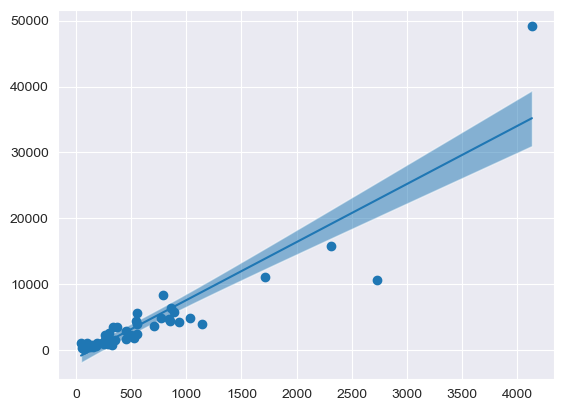

In [25]:
us_reg = simple_regplot(us_gdp_evcs_with_area['GDP (billion dollors)'], us_gdp_evcs_with_area['Public charger number'])
us_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           evcs_density   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                    0.1544
Date:                Thu, 06 Mar 2025   Prob (F-statistic):              0.696
Time:                        16:07:34   Log-Likelihood:                -66.550
No. Observations:                  51   AIC:                             137.1
Df Residuals:                      49   BIC:                             141.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.2144      0.162      1.326      0.191      -0.111       0.539
GDP (billion dollors) -6.826e-05      0.000     -0.393      0.696      -0.000       0.000
==============================================================================
Omnibus:                      112.739   Durbin-Watson:                   2.059
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4634.672
Skew:                           6.785   Prob(JB):                         0.00
Kurtosis:                      47.687   Cond. No.                     1.18e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.18e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

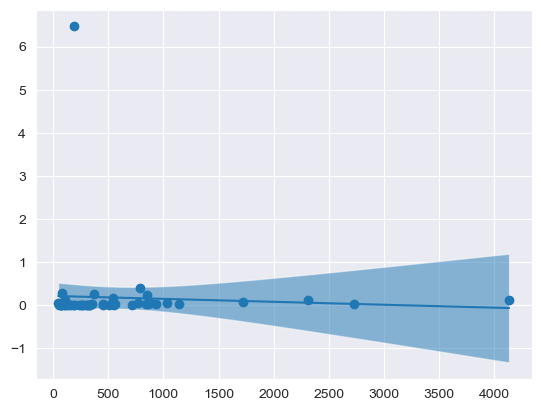

In [26]:
us_reg = simple_regplot(us_gdp_evcs_with_area['GDP (billion dollors)'], us_gdp_evcs_with_area['evcs_density'])
us_reg.summary()

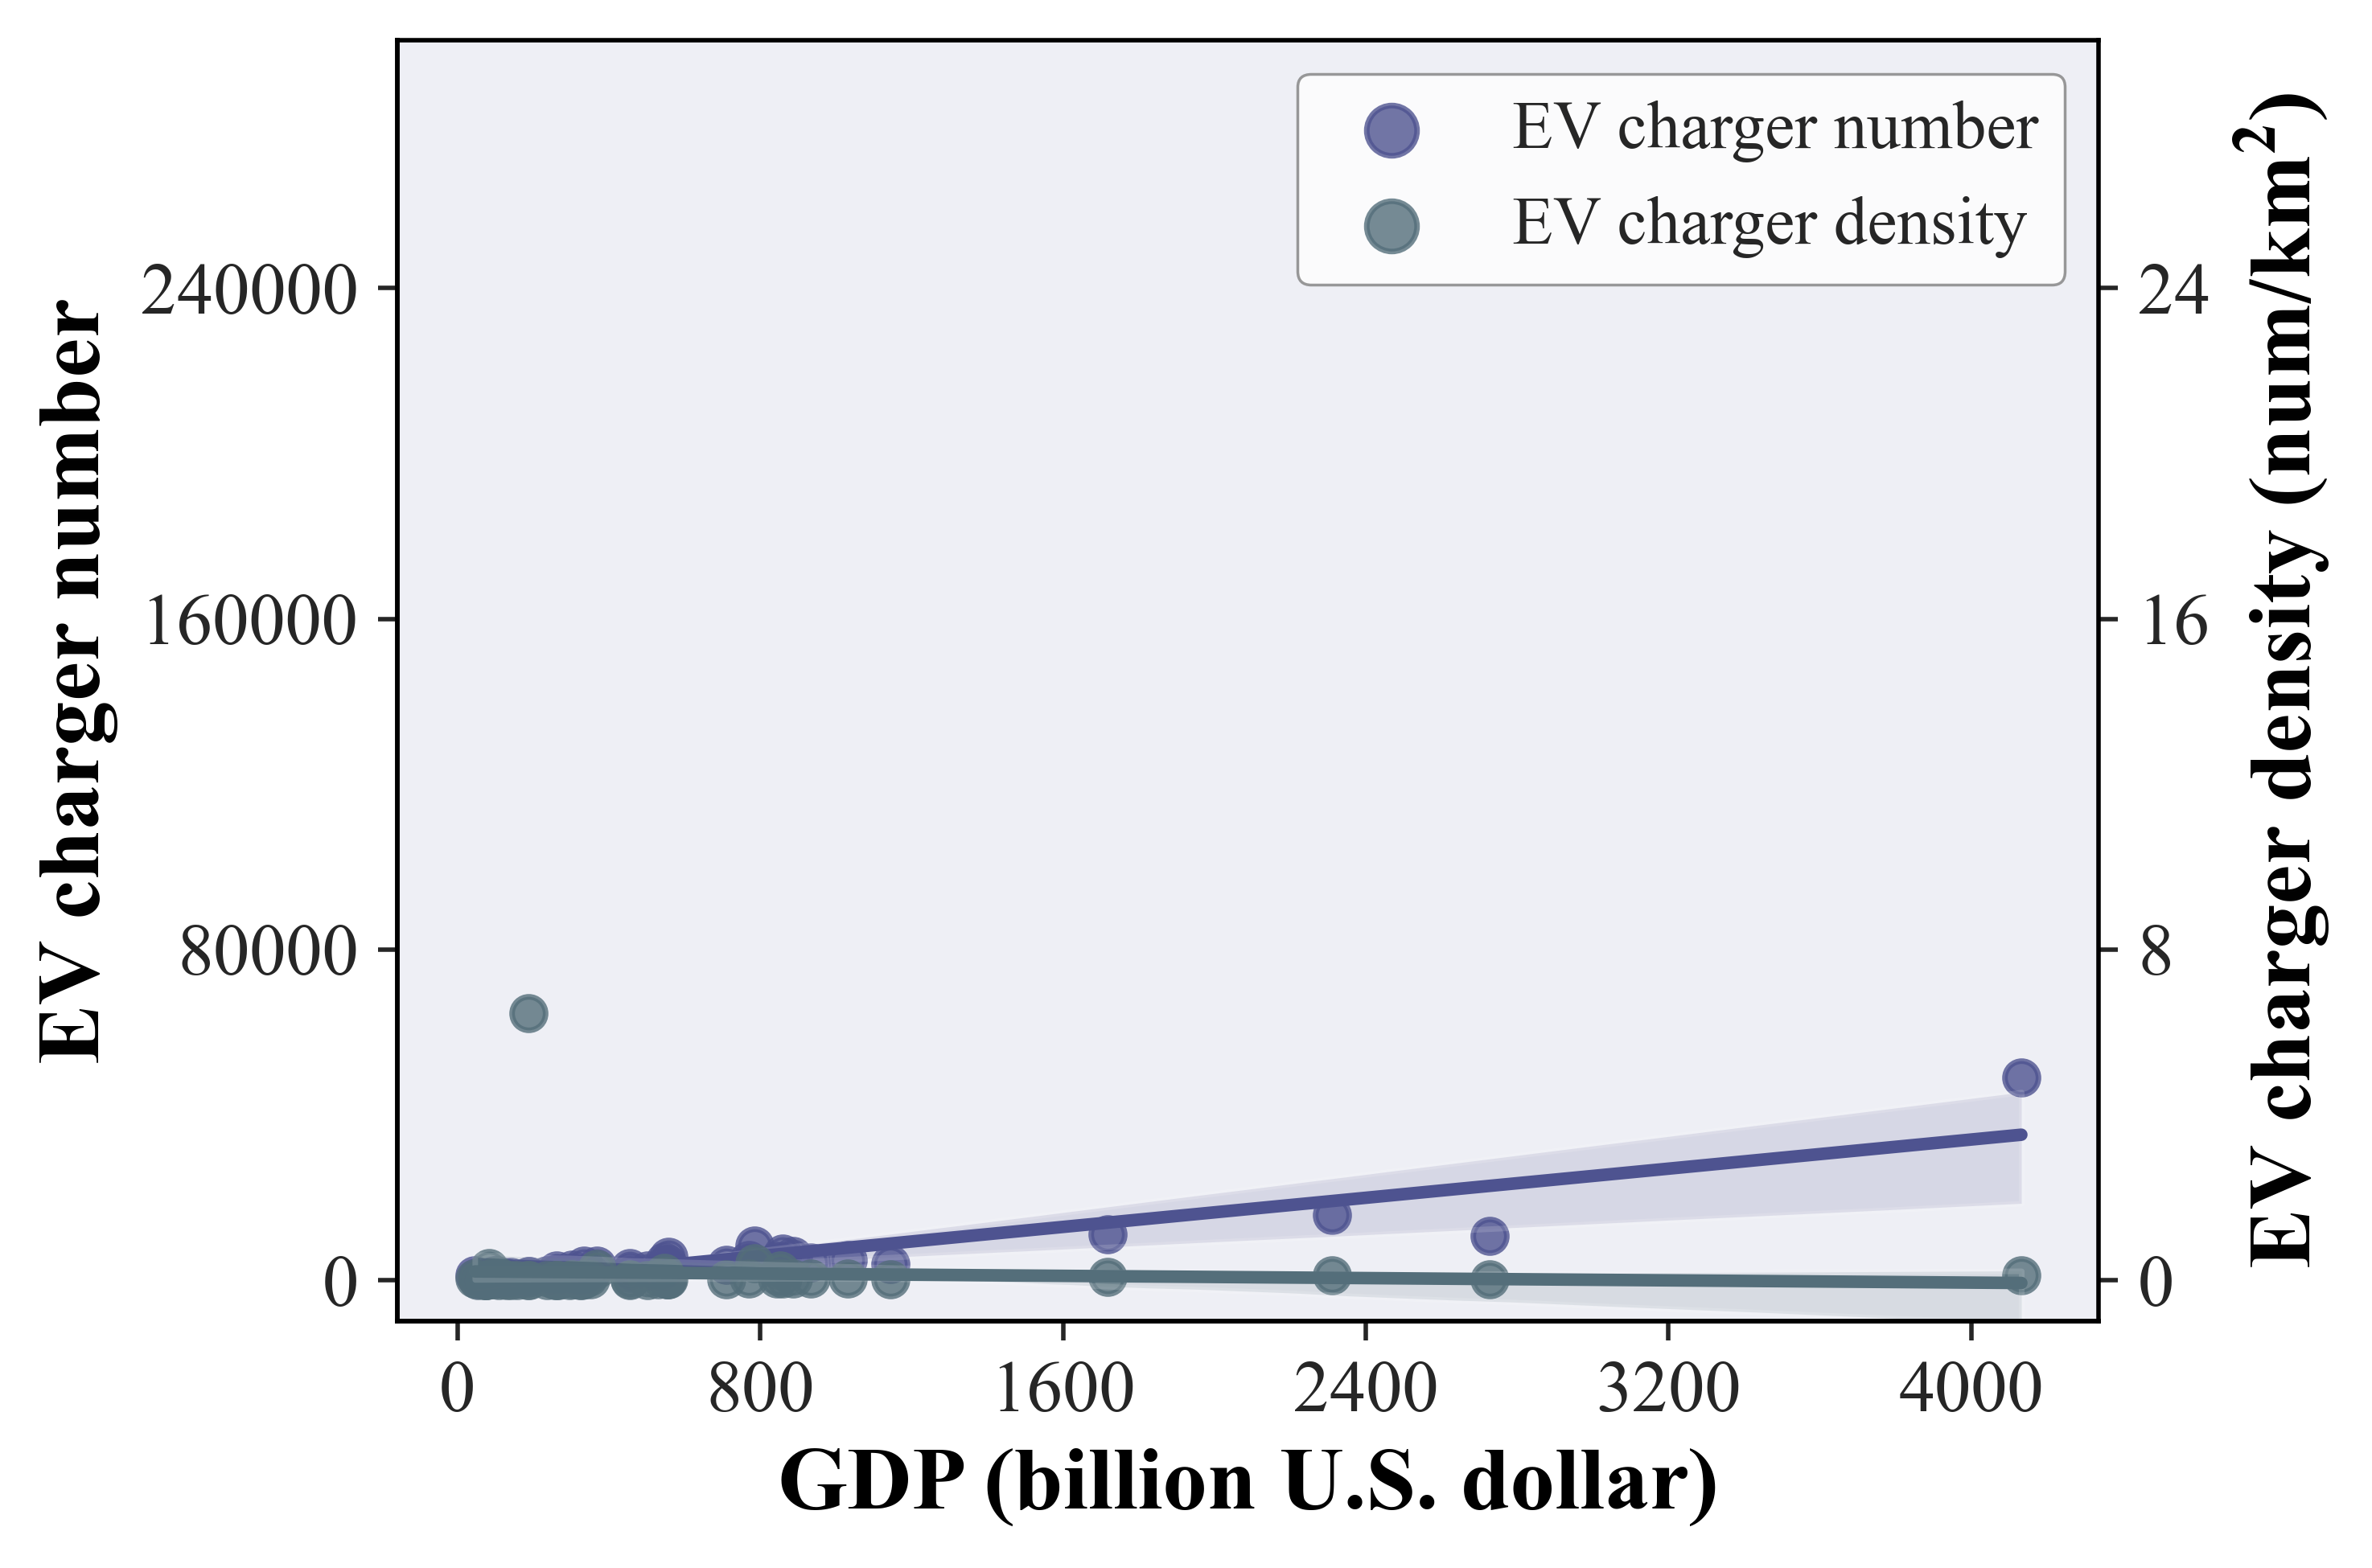

In [28]:
plot_gdp_evcs(dataset=us_gdp_evcs_with_area,
              region='USA',
              x_col='GDP (billion dollors)',
              y1_col='Public charger number',
              y2_col='evcs_density',
              backgroud_color='#DFE0ED',
              back_alpha=0.5,
              line1_color='#4E5390',
              line2_color='#546e7a',
              y1_lim=[-10000, 300000],
              y2_lim=[-1, 30],
              x_nbins=6,
              y1_nbins=5,
              y2_nbins=5,
              x_label='GDP (billion U.S. dollar)',
              legend_loc='best',
              output=True,
              output_filename='gdp_evcs_usa.png'
              )

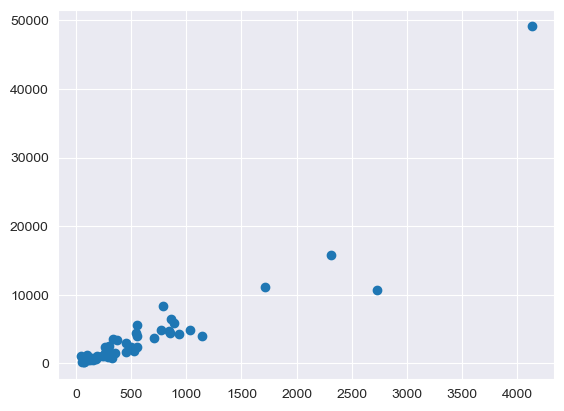

In [27]:
plt.plot(us_gdp_evcs_with_area['GDP (billion dollors)'], us_gdp_evcs_with_area['Public charger number'], 'o')

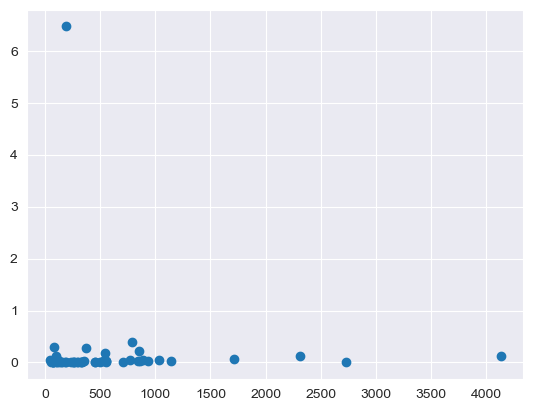

In [28]:
plt.plot(us_gdp_evcs_with_area['GDP (billion dollors)'], us_gdp_evcs_with_area['evcs_density'], 'o')